In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers

from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Activation,BatchNormalization,Input,Embedding,Dot,Dense,Flatten
from tensorflow.keras.callbacks import ModelCheckpoint,LearningRateScheduler,TensorBoard,EarlyStopping

from wordcloud import WordCloud
%matplotlib inline

In [3]:
INPUT_DIR = os.path.join("..","artifacts","raw")


In [4]:
rating_df = pd.read_csv(INPUT_DIR+"/animelist.csv", low_memory=True, usecols=["user_id","anime_id","rating"])

In [5]:
rating_df.head()

,user_id,anime_id,rating
0,0,67,9
1,0,6702,7
2,0,242,10
3,0,4898,0
4,0,21,10


In [6]:
len(rating_df)

5000000

In [7]:
min_rating = min(rating_df["rating"])
max_rating = max(rating_df["rating"])
avg_rating = np.mean(rating_df["rating"])

In [8]:
print(min_rating)      
print(max_rating) 
print(avg_rating)

0
10
4.3068542


In [9]:
#SCALING DOWN THE FEATURES


rating_df["rating"] = rating_df["rating"].apply(lambda x :(x-min_rating)/(max_rating-min_rating)).values.astype(np.float64)

In [10]:

avg_rating = np.mean(rating_df["rating"])
avg_rating

np.float64(0.43068541999999993)

In [11]:
min_rating = min(rating_df["rating"])
min_rating

0.0

In [12]:
max_rating = max(rating_df["rating"])
max_rating

1.0

In [13]:
rating_df.duplicated().sum()

np.int64(0)

In [14]:
user_ids = rating_df["user_id"].unique().tolist()


user2user_encoded = {x : i for i, x in enumerate(user_ids)}
user2user_decoded = {i : x for i, x in enumerate(user_ids)}

In [15]:
print(user2user_encoded)
print(user2user_decoded)

{0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 8: 8, 9: 9, 10: 10, 11: 11, 12: 12, 13: 13, 14: 14, 15: 15, 16: 16, 17: 17, 18: 18, 19: 19, 20: 20, 21: 21, 22: 22, 23: 23, 24: 24, 25: 25, 26: 26, 27: 27, 28: 28, 29: 29, 30: 30, 31: 31, 32: 32, 33: 33, 34: 34, 35: 35, 36: 36, 37: 37, 38: 38, 39: 39, 40: 40, 41: 41, 42: 42, 43: 43, 44: 44, 45: 45, 46: 46, 47: 47, 48: 48, 49: 49, 50: 50, 51: 51, 52: 52, 53: 53, 54: 54, 55: 55, 56: 56, 57: 57, 58: 58, 59: 59, 60: 60, 61: 61, 62: 62, 63: 63, 64: 64, 65: 65, 66: 66, 67: 67, 68: 68, 70: 69, 71: 70, 72: 71, 73: 72, 74: 73, 75: 74, 77: 75, 78: 76, 79: 77, 80: 78, 81: 79, 82: 80, 83: 81, 84: 82, 85: 83, 87: 84, 88: 85, 89: 86, 90: 87, 91: 88, 92: 89, 93: 90, 94: 91, 95: 92, 97: 93, 98: 94, 99: 95, 101: 96, 102: 97, 103: 98, 104: 99, 105: 100, 106: 101, 107: 102, 108: 103, 110: 104, 111: 105, 112: 106, 113: 107, 117: 108, 118: 109, 119: 110, 120: 111, 121: 112, 122: 113, 123: 114, 124: 115, 125: 116, 126: 117, 127: 118, 128: 119, 129: 120, 130: 

In [16]:
rating_df["user"] = rating_df["user_id"].map(user2user_encoded)

In [17]:
rating_df.head()

,user_id,anime_id,rating,user
0,0,67,0.9,0
1,0,6702,0.7,0
2,0,242,1.0,0
3,0,4898,0.0,0
4,0,21,1.0,0


In [18]:
n_users = len(user2user_encoded)
n_users

15186

In [19]:
anime_ids = rating_df["anime_id"].unique().tolist()


anime2anime_encoded = {x : i for i, x in enumerate(anime_ids)}
anime2anime_decoded = {i : x for i, x in enumerate(anime_ids)}

In [20]:
rating_df["animeID"] = rating_df["anime_id"].map(anime2anime_encoded)

In [21]:
rating_df.head()


,user_id,anime_id,rating,user,animeID
0,0,67,0.9,0,0
1,0,6702,0.7,0,1
2,0,242,1.0,0,2
3,0,4898,0.0,0,3
4,0,21,1.0,0,4


In [22]:
n_anime = len(anime2anime_encoded)
n_anime        #NO OF UNINQUE ANIMES

17159

In [23]:
rating_df = rating_df.sample(frac=1,random_state=43).reset_index(drop=True)

In [24]:
X = rating_df[["user","animeID"]]
y = rating_df["rating"]

In [25]:
test_size = 1000
train_indices = rating_df.shape[0]-test_size

In [26]:
X_train, X_test,y_train,y_test = (
    X[:train_indices],
    X[train_indices:],
    y[:train_indices],
    y[train_indices:],
)

In [27]:
X_train = X_train.to_numpy()
X_test = X_test.to_numpy()
y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

In [28]:
len(X_train)

4999000

In [29]:
len(X_test)

1000

In [30]:
type(X_train)

numpy.ndarray

In [31]:
X_train_array = [X_train[:,0], X_train[:,1]]
X_test_array = [X_test[:,0], X_test[:,1]]

In [32]:
type(X_train_array)

list

In [33]:
def RecommenderNet():

    embedding_size = 128

    user = Input(name="user", shape=[1])

    user_embedding = Embedding(name="user_embedding", input_dim=n_users, output_dim=embedding_size)(user)

    anime = Input(name="anime", shape=[1])

    anime_embedding = Embedding(name="anime_embedding", input_dim=n_anime, output_dim=embedding_size)(anime)

    x = Dot(name="dot_product", normalize=True, axes=2)([user_embedding,anime_embedding])

    x = Flatten()(x)


    x = Dense(1, kernel_initializer='he_normal')(x)

    x = BatchNormalization()(x)

    x = Activation("sigmoid")(x)

    model = Model(inputs=[user, anime], outputs=x)

    model.compile(loss="binary_crossentropy", metrics=["mae","mse"],optimizer='Adam')

    return model

In [34]:
model = RecommenderNet()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ anime (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embedding      │ (None, 1, 128)    │  1,943,808 │ user[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ anime_embedding     │ (None, 1, 128)    │  2,196,352 │ anime[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot_product (Dot)   │ (None, 1, 1)      │          0 │ user_embedding[0… │
│                     │                   │            │ anime_embedding[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 1)         │          0 │ dot_product[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │          2 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 1)         │          4 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 1)         │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,140,166 (15.79 MB)

 Trainable params: 4,140,164 (15.79 MB)

 Non-trainable params: 2 (8.00 B)

In [35]:
start_lr = 0.00001
min_lr = 0.00001
max_lr = 0.00005
batch_size = 10000
ramup_epochs = 5
sustain_epochs = 0
exp_decay = 0.8


def lrfn(epoch):
    if epoch < ramup_epochs:
        return (max_lr - start_lr)/ramup_epochs*epoch + start_lr
    elif epoch < ramup_epochs + sustain_epochs:
        return max_lr
    else:
        return (max_lr-min_lr)*exp_decay**(epoch-ramup_epochs-sustain_epochs)+min_lr


In [36]:
lr_callback = LearningRateScheduler(lambda epoch : lrfn(epoch), verbose=0)

checkpoint_filepath = './weights.weights.h5'

model_checkpoint = ModelCheckpoint(filepath=checkpoint_filepath, save_weights_only=True, monitor="val_loss", mode="min", save_best_only=True)

ealry_stopping = EarlyStopping(patience=3, monitor="val_loss", mode="min", restore_best_weights=True)




In [37]:
my_callbacks = [model_checkpoint,lr_callback,ealry_stopping]

In [38]:
history = model.fit(
    x = X_train_array,
    y = y_train,
    batch_size = batch_size,
    epochs=20,
    verbose = 1,
    validation_data = (X_test_array,y_test),
    callbacks = my_callbacks

)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 32s 58ms/step - loss: 0.8016 - mae: 0.3851 - mse: 0.1996 - val_loss: 0.7830 - val_mae: 0.3845 - val_mse: 0.1933 - learning_rate: 1.0000e-05
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 38s 75ms/step - loss: 0.7969 - mae: 0.3834 - mse: 0.1977 - val_loss: 0.8018 - val_mae: 0.3873 - val_mse: 0.1990 - learning_rate: 1.8000e-05
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 36s 65ms/step - loss: 0.7889 - mae: 0.3806 - mse: 0.1946 - val_loss: 0.7984 - val_mae: 0.3867 - val_mse: 0.1978 - learning_rate: 2.6000e-05
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 28s 56ms/step - loss: 0.7773 - mae: 0.3763 - mse: 0.1900 - val_loss: 0.7926 - val_mae: 0.3852 - val_mse: 0.1958 - learning_rate: 3.4000e-05


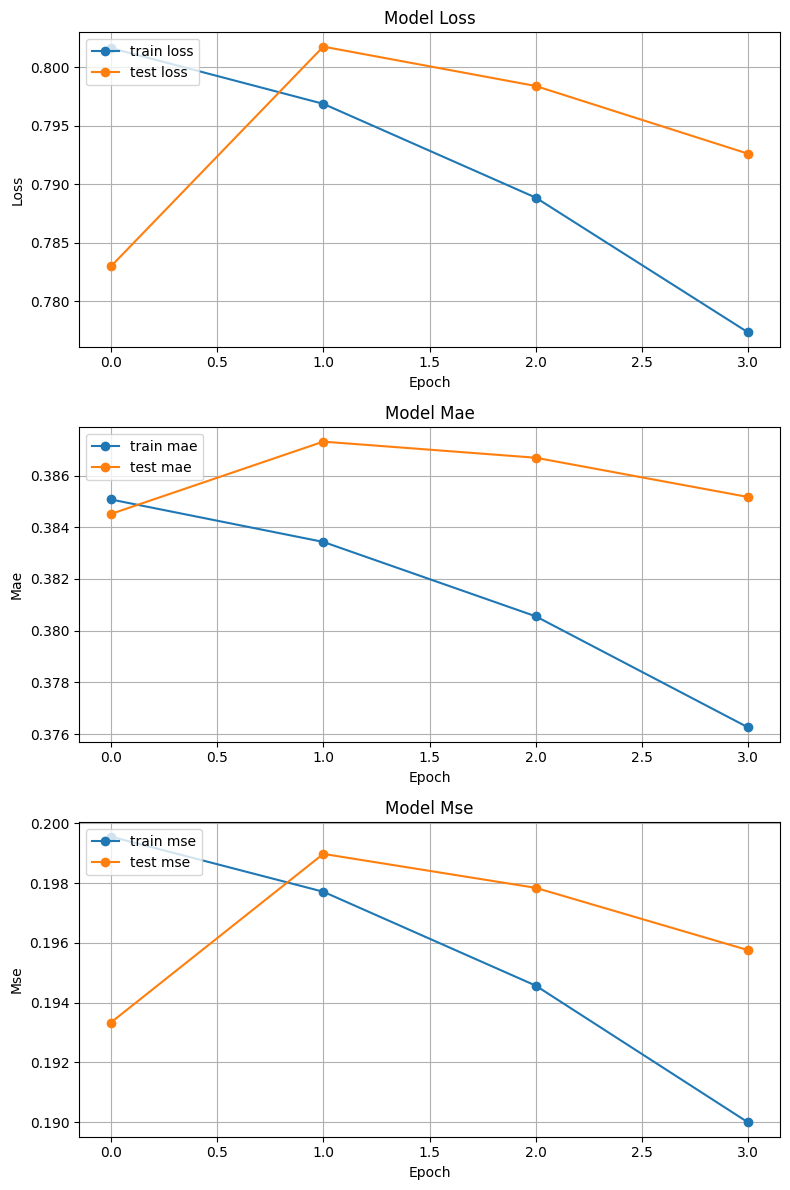

In [39]:
metrics = ["loss", "mae", "mse"]

# Create subplots
fig, axes = plt.subplots(len(metrics), 1, figsize=(8, len(metrics) * 4))

for i, metric in enumerate(metrics):
    ax = axes[i]
    ax.plot(history.history[metric], marker="o", label=f"train {metric}")
    ax.plot(history.history[f"val_{metric}"], marker="o", label=f"test {metric}")
    ax.set_title(f"Model {metric.capitalize()}")
    ax.set_ylabel(metric.capitalize())
    ax.set_xlabel("Epoch")
    ax.legend(loc="upper left")
    ax.grid(True)

plt.tight_layout()
plt.show()

In [40]:
def extract_weights(name,model):
    weight_layer = model.get_layer(name)
    weights = weight_layer.get_weights()[0]
    weights  = weights/np.linalg.norm(weights,axis=1).reshape((-1,1))
    return weights

In [41]:
anime_weights = extract_weights("anime_embedding", model)

In [42]:
user_weights = extract_weights("user_embedding", model)

In [43]:
###Readinf Anime CSV


df = pd.read_csv(INPUT_DIR+ "/anime.csv",low_memory=True)


In [44]:
df.head(2)

,MAL_ID,Name,Score,Genres,English name,Japanese name,Type,Episodes,Aired,Premiered,...,Score-10,Score-9,Score-8,Score-7,Score-6,Score-5,Score-4,Score-3,Score-2,Score-1
0,1,Cowboy Bebop,8.78,"Action, Adventure, Comedy, Drama, Sci-Fi, Space",Cowboy Bebop,カウボーイビバップ,TV,26,"Apr 3, 1998 to Apr 24, 1999",Spring 1998,...,229170.0,182126.0,131625.0,62330.0,20688.0,8904.0,3184.0,1357.0,741.0,1580.0
1,5,Cowboy Bebop: Tengoku no Tobira,8.39,"Action, Drama, Mystery, Sci-Fi, Space",Cowboy Bebop:The Movie,カウボーイビバップ 天国の扉,Movie,1,"Sep 1, 2001",Unknown,...,30043.0,49201.0,49505.0,22632.0,5805.0,1877.0,577.0,221.0,109.0,379.0


In [45]:
df = df.replace("Unknown", np.nan)

In [46]:
def get_anime_name(anime_id):
    try:
        name = df[df.anime_id == anime_id].eng_version.values[0]
        if name is np.nan:
            name = df[df.anime_id == anime_id].Name.values[0]
    except:
        print("error")
    return name            

In [47]:
df["anime_id"] = df["MAL_ID"]
df["eng_version"] = df["English name"]

df["eng_version"] = df.anime_id.apply(lambda x : get_anime_name(x))

In [48]:

anime_67_name = get_anime_name(67)
anime_67_name

'Basilisk'

In [49]:
df.head(1)

,MAL_ID,Name,Score,Genres,English name,Japanese name,Type,Episodes,Aired,Premiered,...,Score-8,Score-7,Score-6,Score-5,Score-4,Score-3,Score-2,Score-1,anime_id,eng_version
0,1,Cowboy Bebop,8.78,"Action, Adventure, Comedy, Drama, Sci-Fi, Space",Cowboy Bebop,カウボーイビバップ,TV,26,"Apr 3, 1998 to Apr 24, 1999",Spring 1998,...,131625.0,62330.0,20688.0,8904.0,3184.0,1357.0,741.0,1580.0,1,Cowboy Bebop


In [50]:
df.sort_values(["Score"], inplace=True, ascending=False,kind="quicksort", na_position="last")

In [51]:
df.head(2)

,MAL_ID,Name,Score,Genres,English name,Japanese name,Type,Episodes,Aired,Premiered,...,Score-8,Score-7,Score-6,Score-5,Score-4,Score-3,Score-2,Score-1,anime_id,eng_version
3971,5114,Fullmetal Alchemist: Brotherhood,9.19,"Action, Military, Adventure, Comedy, Drama, Ma...",Fullmetal Alchemist:Brotherhood,鋼の錬金術師 FULLMETAL ALCHEMIST,TV,64,"Apr 5, 2009 to Jul 4, 2010",Spring 2009,...,199160.0,70045.0,20210.0,9308.0,3222.0,1536.0,2162.0,16806.0,5114,Fullmetal Alchemist:Brotherhood
15926,40028,Shingeki no Kyojin: The Final Season,9.17,"Action, Military, Mystery, Super Power, Drama,...",Attack on Titan Final Season,進撃の巨人 The Final Season,TV,16,"Dec 7, 2020 to ?",Winter 2021,...,26016.0,8793.0,2674.0,1336.0,588.0,382.0,514.0,11061.0,40028,Attack on Titan Final Season


In [52]:
df.columns

Index(['MAL_ID', 'Name', 'Score', 'Genres', 'English name', 'Japanese name',
       'Type', 'Episodes', 'Aired', 'Premiered', 'Producers', 'Licensors',
       'Studios', 'Source', 'Duration', 'Rating', 'Ranked', 'Popularity',
       'Members', 'Favorites', 'Watching', 'Completed', 'On-Hold', 'Dropped',
       'Plan to Watch', 'Score-10', 'Score-9', 'Score-8', 'Score-7', 'Score-6',
       'Score-5', 'Score-4', 'Score-3', 'Score-2', 'Score-1', 'anime_id',
       'eng_version'],
      dtype='object')

In [53]:
df = df[["anime_id", "eng_version", "Score", "Genres","Episodes","Type","Premiered","Members"]]

In [54]:
df.head(2)

,anime_id,eng_version,Score,Genres,Episodes,Type,Premiered,Members
3971,5114,Fullmetal Alchemist:Brotherhood,9.19,"Action, Military, Adventure, Comedy, Drama, Ma...",64,TV,Spring 2009,2248456
15926,40028,Attack on Titan Final Season,9.17,"Action, Military, Mystery, Super Power, Drama,...",16,TV,Winter 2021,733260


In [55]:
def get_anime_info(anime, df):
    if isinstance(anime,int):
        return df[df.anime_id == anime]
    if isinstance(anime, str):
        return df[df.eng_version==anime]

In [56]:
get_anime_info(40028, df)

,anime_id,eng_version,Score,Genres,Episodes,Type,Premiered,Members
15926,40028,Attack on Titan Final Season,9.17,"Action, Military, Mystery, Super Power, Drama,...",16,TV,Winter 2021,733260


In [57]:
get_anime_info("Attack on Titan Final Season", df)

,anime_id,eng_version,Score,Genres,Episodes,Type,Premiered,Members
15926,40028,Attack on Titan Final Season,9.17,"Action, Military, Mystery, Super Power, Drama,...",16,TV,Winter 2021,733260


In [58]:
##reading anime_synopsis.csv


cols = ["MAL_ID", "Name", "Genres", "sypnopsis"]




In [59]:
synopsis_df = pd.read_csv(INPUT_DIR+"/anime_with_synopsis.csv", usecols = cols)

In [60]:
synopsis_df.head(2)

,MAL_ID,Name,Genres,sypnopsis
0,1,Cowboy Bebop,"Action, Adventure, Comedy, Drama, Sci-Fi, Space","In the year 2071, humanity has colonized sever..."
1,5,Cowboy Bebop: Tengoku no Tobira,"Action, Drama, Mystery, Sci-Fi, Space","other day, another bounty—such is the life of ..."


In [61]:
def get_synopsis(anime, df):
    if isinstance(anime,int):
        return synopsis_df[synopsis_df.MAL_ID == anime].sypnopsis.values[0]
    if isinstance(anime,str):
        return synopsis_df[synopsis_df.Name == anime].sypnopsis.values[0]

In [62]:
get_synopsis("Cowboy Bebop", synopsis_df)

'In the year 2071, humanity has colonized several of the planets and moons of the solar system leaving the now uninhabitable surface of planet Earth behind. The Inter Solar System Police attempts to keep peace in the galaxy, aided in part by outlaw bounty hunters, referred to as "Cowboys." The ragtag team aboard the spaceship Bebop are two such individuals. Mellow and carefree Spike Spiegel is balanced by his boisterous, pragmatic partner Jet Black as the pair makes a living chasing bounties and collecting rewards. Thrown off course by the addition of new members that they meet in their travels—Ein, a genetically engineered, highly intelligent Welsh Corgi; femme fatale Faye Valentine, an enigmatic trickster with memory loss; and the strange computer whiz kid Edward Wong—the crew embarks on thrilling adventures that unravel each member\'s dark and mysterious past little by little. Well-balanced with high density action and light-hearted comedy, Cowboy Bebop is a space Western classic an

In [63]:
pd.set_option("max_colwidth",None)

In [64]:
def find_similar_anime(name, anime_weights, anime2anime_encoded, 
                       anime2anime_decoded,df, synopsis_df, n=10, return_dist = False, neg=False):
    try:

        index = get_anime_info(name, df).anime_id.values[0]
        encoded_index = anime2anime_encoded.get(index)
        
        if encoded_index is None:
            raise ValueError(f"Encoded index not found for anime ID: {index}")
        
        weights = anime_weights

        dists = np.dot(weights, weights[encoded_index])

        sorted_dists = np.argsort(dists)


        n = n+1

        if neg:
            closest = sorted_dists[:n]
        else:
            closest = sorted_dists[-n:]

        #print(f"Closest Anime to {name}")

        if return_dist:
            return dists, closest

        SimilarityArr = []

        for close in closest:
            decoded_id = anime2anime_decoded.get(close)

            

            anime_info = get_anime_info(decoded_id,df)        
            
            anime_name = anime_info.eng_version.values[0]

            genre = anime_info.Genres.values[0]

            similarity = dists[close]

            SimilarityArr.append({
                "anime_id" : decoded_id,
                "name" : anime_name,
                "similarity" : similarity,
                "genre" : genre,
                
            })

        Frame = pd.DataFrame(SimilarityArr).sort_values(by="similarity", ascending=False)

        return Frame[Frame.anime_id != index ].drop(["anime_id"],axis=1)
        
    except:
        print("Error occured")    



In [65]:
find_similar_anime("Hunter x Hunter",anime_weights, anime2anime_encoded, anime2anime_decoded,
                   df, synopsis_df)

,name,similarity,genre
9,Long Riders!,0.295139,"Slice of Life, Comedy, Sports, Shounen"
8,Aimai Elegy,0.295128,Music
7,Usavich V,0.293480,Comedy
6,Mobile Suit Gundam: Iron-Blooded Orphans - Urðr Hunt,0.291649,"Action, Sci-Fi, Space, Drama, Mecha"
5,Seitokai Yakuindomo OVA,0.289506,"Comedy, School, Shounen, Slice of Life"
4,Aoki Seimei Hoken,0.278206,Comedy
3,Tamagotchi Honto no Hanashi,0.278037,Kids
2,Burglars of Baghdad Castle,0.272996,"Adventure, Historical, Romance"
1,DS Anime Soushuuhen '98,0.269085,"Comedy, Fantasy"
0,Bokura wa Minna Kawai-sou Specials,0.268966,"Comedy, Seinen"


In [66]:
df.head(10)

,anime_id,eng_version,Score,Genres,Episodes,Type,Premiered,Members
3971,5114,Fullmetal Alchemist:Brotherhood,9.19,"Action, Military, Adventure, Comedy, Drama, Magic, Fantasy, Shounen",64,TV,Spring 2009,2248456
15926,40028,Attack on Titan Final Season,9.17,"Action, Military, Mystery, Super Power, Drama, Fantasy, Shounen",16,TV,Winter 2021,733260
5683,9253,Steins;Gate,9.11,"Thriller, Sci-Fi",24,TV,Spring 2011,1771162
14963,38524,Attack on Titan Season 3 Part 2,9.1,"Action, Drama, Fantasy, Military, Mystery, Shounen, Super Power",10,TV,Spring 2019,1073626
9913,28977,Gintama Season 4,9.1,"Action, Comedy, Historical, Parody, Samurai, Sci-Fi, Shounen",51,TV,Spring 2015,404121
6474,11061,Hunter x Hunter,9.1,"Action, Adventure, Fantasy, Shounen, Super Power",148,TV,Fall 2011,1673924
6006,9969,Gintama Season 2,9.08,"Action, Sci-Fi, Comedy, Historical, Parody, Samurai, Shounen",51,TV,Spring 2011,365579
741,820,Legend of the Galactic Heroes,9.07,"Military, Sci-Fi, Space, Drama",110,OVA,NaN,230168
7261,15417,Gintama:Enchousen,9.04,"Action, Comedy, Historical, Parody, Samurai, Sci-Fi, Shounen",13,TV,Fall 2012,222819
9886,28851,A Silent Voice,9.0,"Drama, School, Shounen",1,Movie,NaN,1387607


In [67]:
def find_similar_users(item_input, user_weights,user2user_encoded,user2user_decoded, n=10, return_dist=False, neg=False):
    try:
        index = item_input
        encoded_index = user2user_encoded.get(index)

        weights = user_weights

        dists = np.dot(weights, weights[encoded_index])
        sorted_dists = np.argsort(dists)

        n = n+1
        if neg:
            closest = sorted_dists[:n]
        else:
            closest = sorted_dists[-n:]


        if return_dist:
            return dists,closest




        SimilaritArr = []
        for close in closest:
            similarity = dists[close]

            if isinstance(item_input,int):
                decoded_id = user2user_decoded.get(close)
                SimilaritArr.append({
                    "similar_users" : decoded_id,
                    "similarity" : similarity

                }) 
        
        simialar_users = pd.DataFrame(SimilaritArr).sort_values(by="similarity", ascending=False)
        simialar_users = simialar_users[simialar_users.similar_users!=item_input]
        return simialar_users
    
    except Exception as e:
        print("error",e)





In [68]:
find_similar_users(1,user_weights,user2user_encoded, user2user_decoded )

,similar_users,similarity
9,7308,0.339820
8,11353,0.334769
7,5646,0.319894
6,10913,0.312797
5,16042,0.307171
4,16048,0.301740
3,11486,0.293183
2,291,0.292996
1,5298,0.292385
0,6590,0.288764


In [69]:
def showWordCloud(all_genres):
    genres_cloud = WordCloud(width=700,height=400, background_color='white',colormap='gnuplot')
    genres_cloud.generate_from_frequencies(all_genres)
    plt.figure(figsize=(10,8))
    plt.imshow(genres_cloud,interpolation="bilinear")
    plt.axis("off")
    plt.show()


In [70]:
from collections import defaultdict

In [71]:
def getFavtGenre(frame, plot=False):
    frame.dropna(inplace=False)
    all_genres = defaultdict(int)

    genre_list = []
    for genres in frame["Genres"]:
        if isinstance(genres, str):
            for genre in genres.split(','):
                genre_list.append(genre)
                all_genres[genre.strip()] += 1

    if plot:
        showWordCloud(all_genres)

    return genre_list                

In [72]:
genre = get_anime_info(65,df)

In [73]:
genre

,anime_id,eng_version,Score,Genres,Episodes,Type,Premiered,Members
46,65,Rozen Maiden:Träumend,7.65,"Action, Comedy, Drama, Magic, Seinen",12,TV,Fall 2005,93768


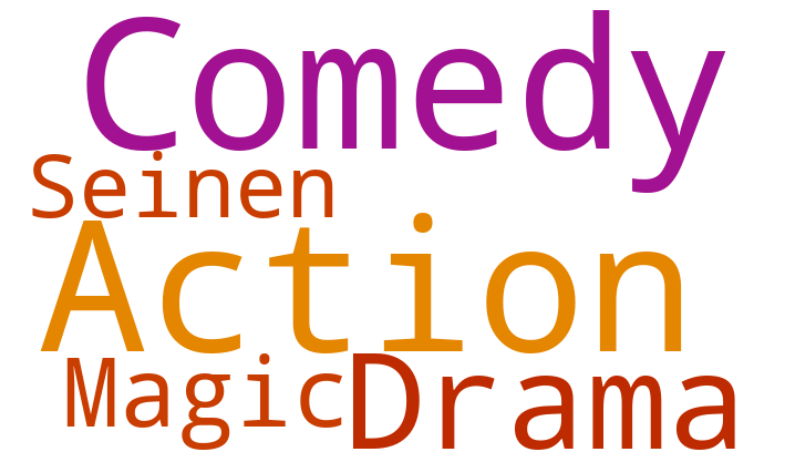

['Action', ' Comedy', ' Drama', ' Magic', ' Seinen']

In [74]:
getFavtGenre(genre,plot=True)

In [75]:
def get_user_preferences(user_id, rating_df, df, verbose=0, plot=False):

    animes_watched_by_user = rating_df[rating_df.user_id==user_id]

    user_rating_percentile = np.percentile(animes_watched_by_user.rating, 75)

    animes_watched_by_user = animes_watched_by_user[animes_watched_by_user.rating >= user_rating_percentile]

    top_animes_by_user = (
        animes_watched_by_user.sort_values(by="rating", ascending=False).anime_id.values


    )

    anime_df_rows = df[df["anime_id"].isin(top_animes_by_user)]

    anime_df_rows = anime_df_rows[["eng_version", "Genres"]]

    if plot :
        getFavtGenre(anime_df_rows, plot)

    return anime_df_rows    





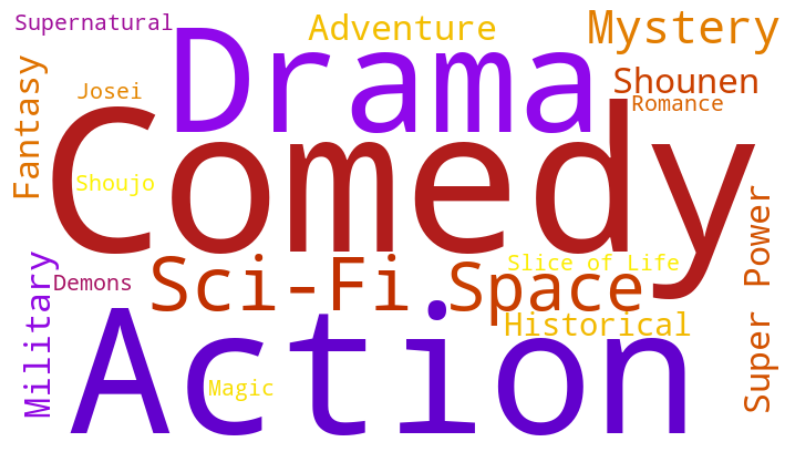

,eng_version,Genres
0,Cowboy Bebop,"Action, Adventure, Comedy, Drama, Sci-Fi, Space"
7449,Attack on Titan,"Action, Military, Mystery, Super Power, Drama, Fantasy, Shounen"
2061,Baccano!,"Action, Comedy, Historical, Mystery, Supernatural"
5238,Princess Jellyfish,"Slice of Life, Comedy, Josei"
8217,Space Dandy,"Sci-Fi, Space, Comedy"
497,Sailor Moon,"Demons, Magic, Romance, Shoujo"


In [76]:
get_user_preferences(1880, rating_df,df, plot=True)

In [77]:
similar_users = find_similar_users(1,user_weights,user2user_encoded, user2user_decoded )

In [83]:
def get_user_recommendation(similar_users, user_pref, df,  synopsis_df, rating_df, n=10):

    recommended_animes = []
    anime_list = []
    

    for user_id in similar_users.similar_users.values:
        pref_list = get_user_preferences(int(user_id), rating_df,df)

        pref_list = pref_list[~pref_list.eng_version.isin(user_pref.eng_version.values)]

        if not pref_list.empty:

            anime_list.append(pref_list.eng_version.values)

    if anime_list:

            anime_list = pd.DataFrame(anime_list)

            sorted_list = pd.DataFrame(pd.Series(anime_list.values.ravel()).value_counts()).head(n)

            for i, anime_name in enumerate(sorted_list.index):
                n_user_pref = sorted_list[sorted_list.index == anime_name].values[0][0]

                if isinstance(anime_name,str):    

                    frame = get_anime_info(anime_name,df)

                    anime_id = frame.anime_id.values

                    genre = frame.Genres.values[0]

                    #synopsis = get_synopsis(int(anime_id), synopsis_df)

                    recommended_animes.append({
                        "n" : n_user_pref,
                        "anime_name" : anime_name,
                        "genre" : genre,
                        #"synopsis" : synopsis
                    })

    return pd.DataFrame(recommended_animes).head(n)        
                    




    

In [84]:
similar_users = find_similar_users(11880,user_weights,user2user_encoded, user2user_decoded )
user_pref = get_user_preferences(11880, rating_df,df, plot=False)

In [85]:
get_user_recommendation(similar_users,user_pref,df,synopsis_df,rating_df)

,n,anime_name,genre
0,4,Your Name.,"Romance, Supernatural, School, Drama"
1,4,Your Lie in April,"Drama, Music, Romance, School, Shounen"
2,4,Angel Beats!,"Action, Comedy, Drama, School, Supernatural"
3,4,"No Game, No Life","Game, Adventure, Comedy, Supernatural, Ecchi, Fantasy"
4,4,The Promised Neverland,"Sci-Fi, Mystery, Horror, Psychological, Thriller, Shounen"
5,3,Kaguya-sama:Love is War,"Comedy, Psychological, Romance, School, Seinen"
6,3,5 Centimeters Per Second,"Drama, Romance, Slice of Life"
7,3,Golden Time,"Comedy, Drama, Romance"
8,3,Clannad ~After Story~,"Slice of Life, Comedy, Supernatural, Drama, Romance"
9,3,Attack on Titan Season 3 Part 2,"Action, Drama, Fantasy, Military, Mystery, Shounen, Super Power"


In [86]:
#HYBRID RECOMMENDATION##

In [87]:
def hybrid(user_id, user_weight=0.5, content_weight=0.5):

    similar_users = find_similar_users(user_id, user_weights, user2user_encoded, user2user_decoded)

    user_pref = get_user_preferences(user_id, rating_df, df)

    user_recommended_anime = get_user_recommendation(similar_users, user_pref, df, synopsis_df, rating_df)

    user_recommended_anime_list = user_recommended_anime["anime_name"].tolist()




    content_recommended_anime = []

    for anime in user_recommended_anime_list:
        similar_anime = find_similar_anime(anime, anime_weights, anime2anime_encoded, anime2anime_decoded, df,synopsis_df)

        if similar_anime is not None and not similar_anime.empty:

            content_recommended_anime.extend(similar_anime["name"].tolist())
        else:
            print(f"No Similar anime Found {anime}")


    combined_scores = {}

    for anime in user_recommended_anime_list:
        combined_scores[anime] = combined_scores.get(anime, 0)+user_weight
    for anime in content_recommended_anime:
        combined_scores[anime] = combined_scores.get(anime,0)+content_weight


    sorted_animes = sorted(combined_scores.items(), key=lambda x : x[1], reverse=True)

    return [anime for anime , score in sorted_animes[:10] ]









In [89]:
hybrid(11880)

['Your Name.',
 'Your Lie in April',
 'Angel Beats!',
 'No Game, No Life',
 'The Promised Neverland',
 'Kaguya-sama:Love is War',
 '5 Centimeters Per Second',
 'Golden Time',
 'Clannad ~After Story~',
 'Attack on Titan Season 3 Part 2']